# Basic usage

This notebook walks through the core workflow:
- Creating a hypergrid with `DenseHypergrid` and `SparseHypergrid`
- Fitting and incrementally updating
- Inspecting mass, edges, and shape
- Converting to a dense array and probability vector
- Basic visualizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hypergrid import DenseHypergrid, SparseHypergrid, compute_edges

## 1. Generating sample data

In [2]:
rng = np.random.default_rng(42)
data = rng.standard_normal((5000, 3))
print(f"Data shape: {data.shape}")
print(f"Column means: {data.mean(axis=0).round(3)}")
print(f"Column stds:  {data.std(axis=0).round(3)}")

Data shape: (5000, 3)
Column means: [ 0.007 -0.001 -0.035]
Column stds:  [1.006 1.006 1.   ]


## 2. Computing bin edges automatically

In [3]:
edges = compute_edges(data, method="fd")  # Freedman-Diaconis

for d, e in enumerate(edges):
    print(f"Dim {d}: {len(e)-1} bins  [{e[0]:.2f}, {e[-1]:.2f}]")

Dim 0: 51 bins  [-3.89, 4.15]
Dim 1: 47 bins  [-3.65, 3.45]
Dim 2: 51 bins  [-4.39, 3.44]


## 3. DenseHypergrid — numpy backend

In [4]:
dense = DenseHypergrid(edges)
dense.fit(data)

mass = dense.get_mass()  # {tuple_index: float}
print(f"Non-empty bins: {len(mass)}")
print(f"Total mass:     {sum(mass.values()):.0f}  (should be ~{len(data)})")
print(f"Grid shape:     {dense.shape}")

Non-empty bins: 4144
Total mass:     4997  (should be ~5000)
Grid shape:     [51, 47, 51]


## 4. Incremental update

In [5]:
new_batch = rng.standard_normal((500, 3))
dense.update(new_batch)

print(f"Total mass after update: {sum(dense.get_mass().values()):.0f}")

Total mass after update: 5497


## 5. SparseHypergrid — sparse dict backend

In [6]:
sparse = SparseHypergrid(edges)
sparse.fit(data)

print(f"Non-empty bins (sparse): {len(sparse.get_mass())}")
print(f"Grid cells total:        {int(np.prod(sparse.shape))}")

Non-empty bins (sparse): 4144
Grid cells total:        122247


## 6. Converting to a dense array and probability vector

In [7]:
arr = dense.to_dense()  # numpy array
print(f"Dense array shape: {arr.shape}")
print(f"Array sum:         {arr.sum():.0f}")

vec = dense.to_vector()  # flat probability vector
print(f"\nProbability vector length: {len(vec)}")
print(f"Vector sum:                {vec.sum():.6f}")

Dense array shape: (51, 47, 51)
Array sum:         5497

Probability vector length: 122247
Vector sum:                1.000000


## 7. Visualizations

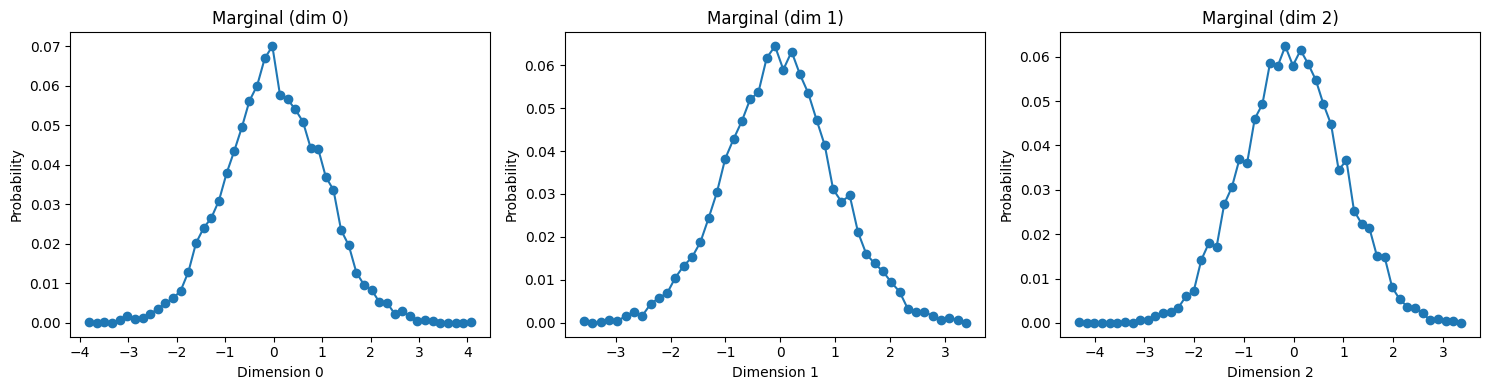

In [8]:
dense.plot_all_marginals()

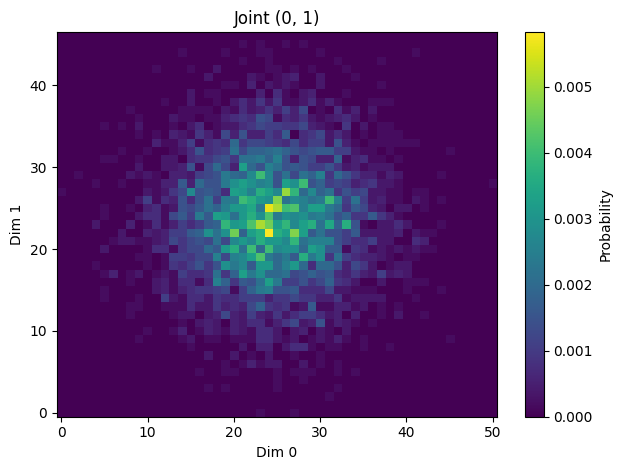

In [9]:
dense.plot_joint(dim_x=0, dim_y=1)

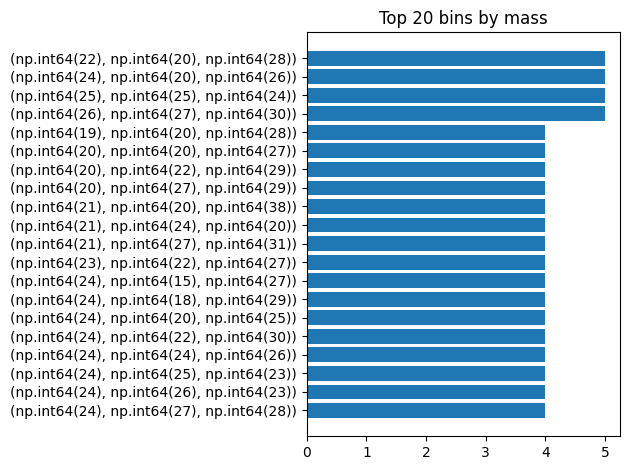

In [10]:
dense.plot_top_bins(k=20)

## 8. Rebinning onto coarser edges

In [11]:
coarse_edges = [np.linspace(e[0], e[-1], 6) for e in edges]
rebinned = dense.rebin_to(coarse_edges)  # returns dict

print(f"Bins in rebinned grid: {len(rebinned)}")
print(f"Mass conserved:        {sum(rebinned.values()):.0f}")

Bins in rebinned grid: 78
Mass conserved:        5497
